In [4]:
# Install dependencies (Run this cell first if you see ModuleNotFoundError)
!pip install numpy tensorflow opencv-python matplotlib scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import os

# Debugging: Check current working directory and dataset path
print(f"Current working directory: {os.getcwd()}")
dataset_path = 'dataset/brain-tumor-mri-dataset/'
if os.path.exists(dataset_path):
    print(f"Dataset path found: {dataset_path}")
    print("Classes found:", os.listdir(dataset_path))
else:
    print(f"Dataset path NOT found: {dataset_path}")
    print("Please ensure the 'dataset' folder is in the same directory as this notebook.")

Current working directory: c:\Users\bunny\pad project
Dataset path found: dataset/brain-tumor-mri-dataset/
Classes found: ['glioma', 'meningioma', 'notumor', 'pituitary']


Loading images from glioma...
Loading images from meningioma...
Loading images from notumor...
Loading images from pituitary...
Loaded 7153 images with shape (7153, 128, 128, 3)
Labels: (array([0, 1, 2, 3]), array([1621, 1775, 2000, 1757]))


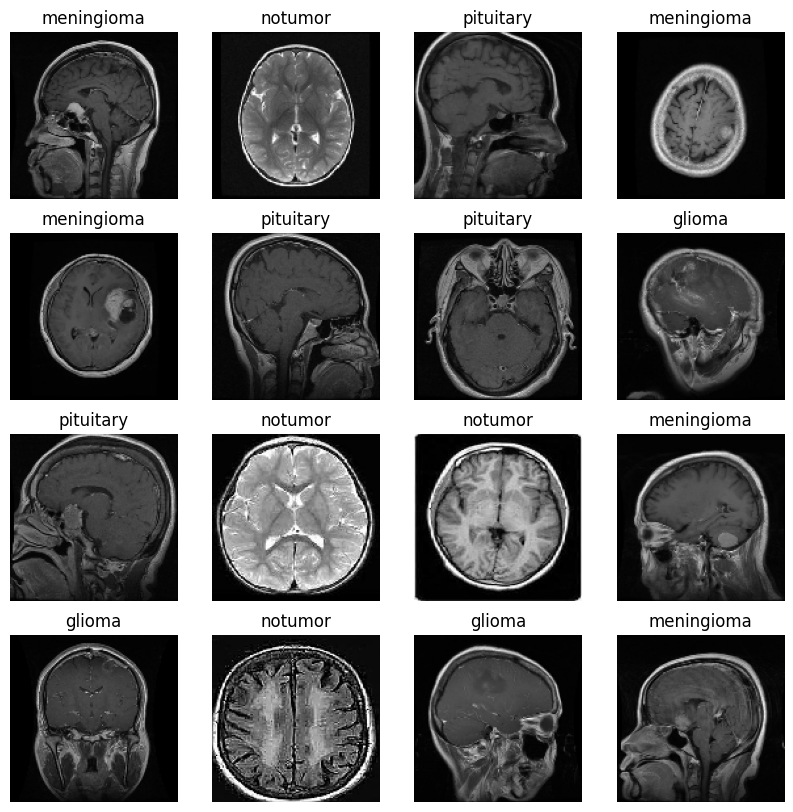

Training set shape: (5722, 128, 128, 3)
Testing set shape: (1431, 128, 128, 3)


In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle

# Path to the dataset folder
dataset_path = 'dataset/brain-tumor-mri-dataset/'

# Classes (based on subfolder names)
classes = ['glioma', 'meningioma', 'notumor', 'pituitary']
num_classes = len(classes)

# Initialize lists for images and labels
images = []
labels = []
image_size = (128, 128)  # Resize all images to 128x128

# Loop through each class folder
for i, class_name in enumerate(classes):
    class_path = os.path.join(dataset_path, class_name)
    if os.path.exists(class_path):
        print(f"Loading images from {class_name}...")
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            try:
                # Load and preprocess the image
                img = load_img(img_path, target_size=image_size)
                img_array = img_to_array(img) / 255.0  # Normalize to [0, 1]
                images.append(img_array)
                labels.append(i)  # Label as class index
            except Exception as e:
                # Skip non-image files or errors
                pass 
    else:
        print(f"Folder {class_path} not found.")

# Convert to numpy arrays
images = np.array(images)
labels = np.array(labels)

# Shuffle the dataset
images, labels = shuffle(images, labels, random_state=42)

# Print summary
print(f"Loaded {len(images)} images with shape {images.shape}")
print(f"Labels: {np.unique(labels, return_counts=True)}")

# Visualization: Display sample images
plt.figure(figsize=(10, 10))
for i in range(min(16, len(images))):
    plt.subplot(4, 4, i + 1)
    plt.imshow(images[i])
    plt.title(classes[labels[i]])
    plt.axis('off')
plt.show()

# Split into Training and Testing sets
if len(images) > 0:
    X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)
    print(f"Training set shape: {X_train.shape}")
    print(f"Testing set shape: {X_test.shape}")
else:
    print("No images loaded. Please check dataset path.")

### Class Distribution Visualization

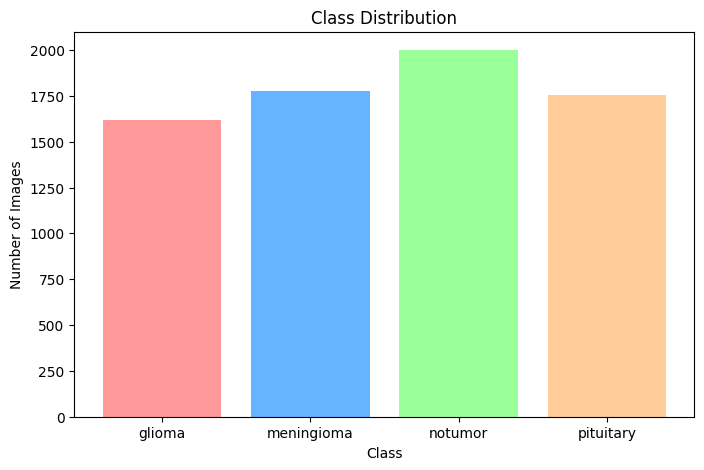

In [7]:
# Visualization: Class Distribution
unique, counts = np.unique(labels, return_counts=True)
plt.figure(figsize=(8, 5))
plt.bar(classes, counts, color=['#ff9999','#66b3ff','#99ff99','#ffcc99'])
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.show()

### Sample Images Per Class

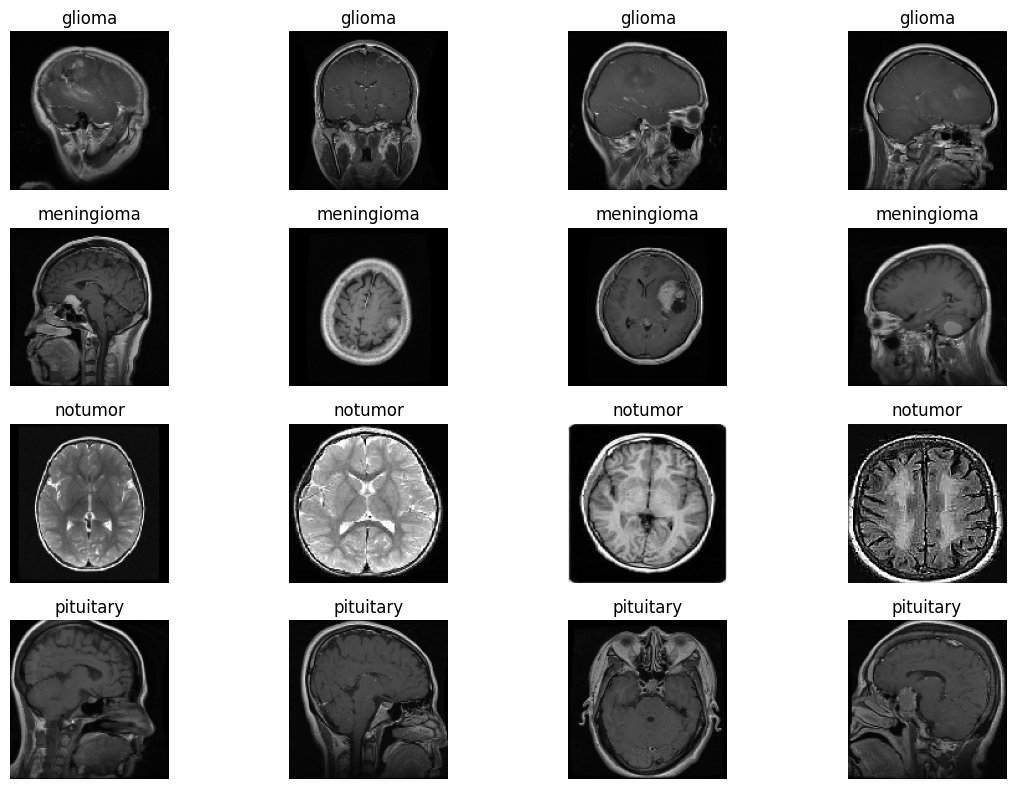

In [8]:
# Visualization: Sample Images from Each Class
plt.figure(figsize=(12, 8))
for i, class_name in enumerate(classes):
    # Get indices of images belonging to this class
    indices = np.where(labels == i)[0]
    sample_indices = indices[:4] # Select first 4 images
    
    for j, idx in enumerate(sample_indices):
        plt.subplot(4, 4, i * 4 + j + 1)
        plt.imshow(images[idx])
        plt.title(class_name)
        plt.axis('off')
plt.tight_layout()
plt.show()

### Model Building

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Build CNN Model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(len(classes), activation='softmax')
])

model.summary()

c:\Users\bunny\pad project\.venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,940,868 (49.37 MB)

 Trainable params: 12,940,868 (49.37 MB)

 Non-trainable params: 0 (0.00 B)

### Compiling and Training

Epoch 1/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 65s 342ms/step - accuracy: 0.5972 - loss: 0.9380 - val_accuracy: 0.7855 - val_loss: 0.4909
Epoch 2/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 56s 310ms/step - accuracy: 0.8452 - loss: 0.4095 - val_accuracy: 0.8889 - val_loss: 0.3031
Epoch 3/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 56s 314ms/step - accuracy: 0.9013 - loss: 0.2613 - val_accuracy: 0.9231 - val_loss: 0.1968
Epoch 4/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 58s 325ms/step - accuracy: 0.9419 - loss: 0.1729 - val_accuracy: 0.9280 - val_loss: 0.2022
Epoch 5/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 58s 323ms/step - accuracy: 0.9634 - loss: 0.1027 - val_accuracy: 0.9315 - val_loss: 0.1895
Epoch 6/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 56s 314ms/step - accuracy: 0.9708 - loss: 0.0848 - val_accuracy: 0.9434 - val_loss: 0.1877
Epoch 7/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 56s 311ms/step - accuracy: 0.9826 - loss: 0.0544 - val_accuracy: 0.9504 - val_loss: 0.1417
Epoch 8/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 56s 313ms/step - accuracy: 0.9874 - loss: 0

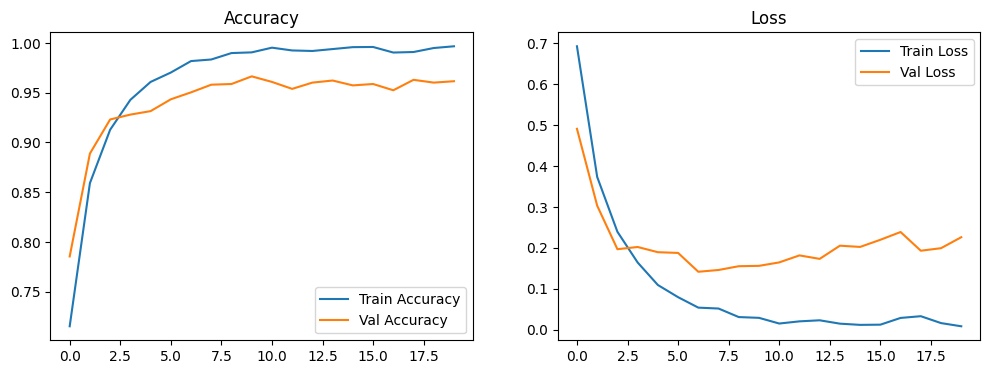

In [10]:
# Compile Model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train Model
history = model.fit(X_train, y_train, epochs=20, validation_data=(X_test, y_test))

# Plot Training History
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss')
plt.show()

### Evaluation


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step
Classification Report:
              precision    recall  f1-score   support

      glioma       0.97      0.95      0.96       318
  meningioma       0.96      0.91      0.93       355
     notumor       0.98      0.99      0.98       433
   pituitary       0.94      1.00      0.97       325

    accuracy                           0.96      1431
   macro avg       0.96      0.96      0.96      1431
weighted avg       0.96      0.96      0.96      1431



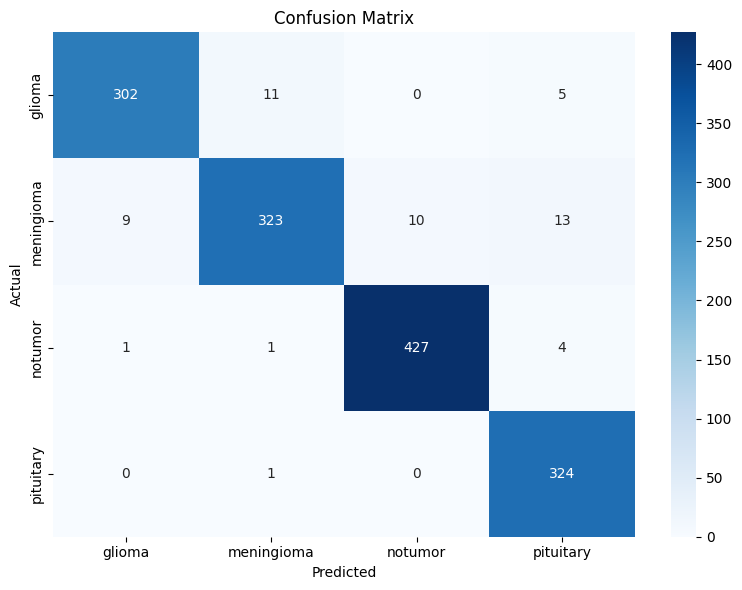

In [12]:
!pip install seaborn -q
# Classification Report & Confusion Matrix
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Predict on test set
y_pred = np.argmax(model.predict(X_test), axis=1)

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=classes))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step


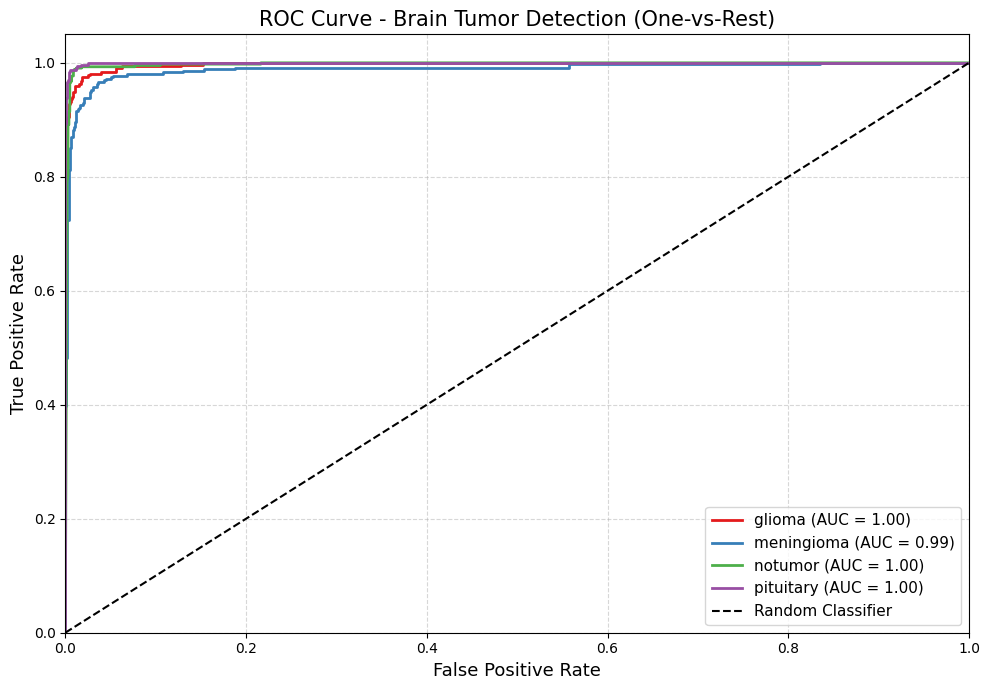

ROC Curve plotted and saved as roc_curve.png


In [16]:


# ROC Curve (One-vs-Rest for Multiclass)
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

# Binarize the labels for one-vs-rest
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3])
y_score = model.predict(X_test)  # predicted probabilities

colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']

fig, ax = plt.subplots(figsize=(10, 7))

for i, (class_name, color) in enumerate(zip(classes, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2,
             label=f'{class_name} (AUC = {roc_auc:.2f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate', fontsize=13)
ax.set_title('ROC Curve - Brain Tumor Detection (One-vs-Rest)', fontsize=15)
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=100)
plt.show()
print('ROC Curve plotted and saved as roc_curve.png')

In [17]:
model.save('brain_tumor_detector.h5')

In [19]:
from tensorflow.keras.models import load_model
# Load the trained model
model = load_model('brain_tumor_detector.h5')

detect_and_display() is ready!
Usage: detect_and_display("path/to/mri_image.jpg", model)


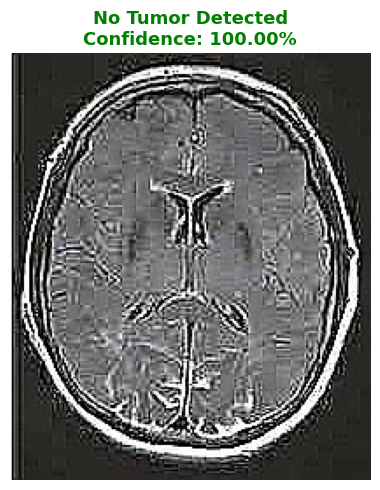

Result     : No Tumor Detected
Confidence : 100.00%
All Scores :
  glioma      : 0.00%
  meningioma  : 0.00%
  notumor     : 100.00%
  pituitary   : 0.00%


In [23]:
%matplotlib inline
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

# Class labels (must match training order)
class_labels = ['glioma', 'meningioma', 'notumor', 'pituitary']

def detect_and_display(img_path, model, image_size=128):
    """
    Detects brain tumor from an MRI image and displays the result.
    - Shows 'No Tumor Detected' if notumor class is predicted.
    - Otherwise shows the tumor type and confidence score.
    """
    try:
        # Load and preprocess the image
        img = load_img(img_path, target_size=(image_size, image_size))
        img_array = img_to_array(img) / 255.0
        img_batch = np.expand_dims(img_array, axis=0)

        # Predict
        predictions = model.predict(img_batch, verbose=0)
        predicted_index = np.argmax(predictions, axis=1)[0]
        confidence = np.max(predictions, axis=1)[0] * 100

        # Determine result label
        predicted_label = class_labels[predicted_index]
        if predicted_label == 'notumor':
            result = 'No Tumor Detected'
            color = 'green'
        else:
            result = f'Tumor Detected: {predicted_label.capitalize()}'
            color = 'red'

        # Display
        plt.figure(figsize=(5, 5))
        plt.imshow(load_img(img_path))
        plt.axis('off')
        plt.title(f'{result}\nConfidence: {confidence:.2f}%',
                  fontsize=13, color=color, fontweight='bold')
        plt.tight_layout()
        plt.show()

        print(f'Result     : {result}')
        print(f'Confidence : {confidence:.2f}%')
        print('All Scores :')
        for i, label in enumerate(class_labels):
            print(f'  {label:12s}: {predictions[0][i]*100:.2f}%')

    except Exception as e:
        print('Error processing the image:', str(e))

print('detect_and_display() is ready!')
print('Usage: detect_and_display("path/to/mri_image.jpg", model)')

detect_and_display(r'C:\Users\bunny\pad project\dataset\brain-tumor-mri-dataset\notumor\no-0001.jpg', model)
